In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
                              
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"


### Choose model for attribution

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer  

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen2.5-3B"
# model_name = "Qwen/Qwen2.5-1.5B"
if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

/home/jl3499/conda/exp/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 146/146 [00:00<00:00, 327.82it/s]


### Set input strings

In [3]:
### Lorenz system
# string = '80,68,57,52,50,49,48,46,42,35,23,14,24,40,49,54,57,60,66,74,79,74,64,58,55,55,57,61,68,77,80,71,60,54,52,51,52,53,55,61,70,83,83,66,53,47,44,41,36,28,22,23,32,40,44,44,43,40,33,24,19,26,37,44,47,47,47,45,40,32,21,16,28,42,49,52,55,58,63,71,80,79,67,58,53,51,51,51,52,55,59,69,82,84,69,54,47,43,40,35,28,22,24,32,39,43,43,41,37,30,22,22,31,39,44,45,44,41,36,27,19,22,34,43,47,49,49,48,47,45,40,31,18,15,31,46,53,57,60,65,72,77,75,67,60,57,57,59,64,71,78,77,68,60,56,55,56,60,66,75,81,75,63,56,53,52,52,54,57,62,73,84'

### Lobe switching
string = '51,53,55,58,65,75,83,76,62,54,51,49,49,47,45,40,29,16,17,35,48,54,57,62,68,76,79,72,63,57,56,58,61,69,78,80,71,60,55,54,54,57,62,72,82,80,66,55,51,49,48,46,42,34,22,14,26,42,50,54,57,61,68,77,81,72,61,55,53,53,55,59,67,79,84,71,58,51,48,46,43,38,28,18,20,34,45,49,51,53,55,59,67,80,84,71,57,49,46,44,39,32,22,19,28,40,46,48,48,47,44,39,29,16,18,35,47,52,55,59,64,73,80,77,65,57,54,53,55,58,64,75,84,77,62,53,49,47,45,42,34,23,16,25,40,48,51,53,55,60,68,79,83,71,58,51,49,47,44,40,32,20,17,30,43,49,52,54,57,63,73,83,79,65,55,50,49,47,45'

### Lorenz with drift 0.2
# string = '29,30,31,33,36,40,45,45,39,34,32,31,31,30,30,28,25,19,14,19,28,33,35,37,39,42,47,49,47,42,39,38,38,39,42,46,50,52,48,42,39,38,38,39,40,41,44,49,56,56,48,41,38,37,36,33,30,27,28,32,37,39,39,39,37,34,30,28,31,37,41,42,43,43,42,40,36,30,28,35,42,46,48,49,51,54,58,63,62,56,52,50,49,49,50,50,52,55,60,67,68,59,52,49,48,46,44,40,38,39,44,47,49,50,49,47,43,40,40,45,49,52,53,52,51,48,44,40,43,49,53,56,57,57,57,56,55,53,48,42,42,50,58,61,63,65,68,72,75,73,69,66,65,65,67,69,73,77,76,72,68,66,66,67,69,73,78,80,77,72,68,67,67,67,68,70,73,79,84'

### Lorenz with drift 0.4
# string = '21,22,23,25,27,30,33,33,30,26,25,24,24,24,24,23,21,17,14,18,24,27,29,30,32,34,37,39,38,35,33,32,32,33,35,38,41,42,39,36,34,34,34,34,35,36,38,42,46,46,41,37,35,35,34,32,30,28,29,32,35,37,37,37,36,34,32,30,33,37,40,41,41,41,41,40,37,34,33,37,42,45,46,47,48,50,54,57,56,53,50,49,48,49,49,50,51,53,56,61,62,57,52,50,49,48,47,45,43,44,47,50,51,52,51,50,48,46,46,49,53,54,55,55,54,53,50,48,49,53,57,58,59,59,60,59,59,58,54,50,50,56,61,64,65,67,69,72,73,73,70,68,68,68,69,71,74,76,76,73,71,70,70,71,72,75,78,80,78,75,72,72,72,72,73,74,77,81,84'

### Lorenz with drift 0.6
# string = '18,19,19,20,22,25,27,28,25,22,21,21,21,21,21,21,19,16,14,17,22,24,26,27,28,30,32,34,33,31,29,29,29,30,32,34,36,37,35,33,32,31,32,32,33,34,35,38,42,42,38,35,34,33,33,32,30,29,30,32,35,36,36,36,36,35,33,32,34,37,39,40,41,41,40,40,38,35,35,38,42,44,45,46,47,49,51,54,54,51,49,48,48,48,49,49,50,52,55,58,59,55,52,50,50,49,48,47,46,47,49,51,52,53,53,52,50,49,49,52,54,56,56,56,56,55,53,51,53,56,58,60,60,61,61,61,61,60,58,55,55,59,63,65,66,68,69,71,73,73,71,69,69,69,70,72,74,76,76,74,72,72,72,73,74,76,78,80,79,76,75,74,74,75,75,77,79,82,84'

### Brownian motion
# string = '28,28,31,26,29,27,19,16,19,21,15,18,18,20,21,16,18,14,22,26,26,21,21,22,16,27,29,37,32,40,33,30,33,33,21,16,20,30,35,34,37,32,34,28,28,27,31,29,35,34,39,42,33,34,34,30,31,24,26,29,30,43,44,45,41,42,38,44,41,42,51,57,58,65,65,69,69,65,67,71,70,64,62,50,47,41,51,49,41,45,44,45,46,47,45,50,52,50,49,44,46,49,52,55,55,63,62,62,60,60,59,69,71,63,61,54,58,65,63,66,65,67,75,74,68,71,74,77,82,79,69,74,72,66,60,66,67,68,73,69,64,60,54,53,48,48,46,46,49,56,63,64,65,63,68,75,72,76,74,73,74,72,77,69,66,65,60,62,55,55,48,47,49,60,66,74,74,84'
# string = "34,32,35,36,32,21,25,30,23,31,29,41,44,42,48,48,49,49,48,51,55,57,65,59,57,60,55,62,65,64,67,64,57,61,66,66,66,56,53,51,52,58,56,52,56,56,50,55,51,49,44,46,50,49,51,48,59,66,63,65,70,72,68,68,71,73,69,71,66,57,57,62,64,70,78,80,77,77,70,70,70,71,75,66,69,67,70,71,66,70,67,69,67,65,65,74,77,77,84,84,83,79,80,80,77,68,68,68,66,62,57,55,61,62,54,57,55,66,65,64,65,66,67,67,66,63,62,56,54,51,49,47,46,48,47,47,49,47,47,48,40,43,41,25,27,21,26,21,20,23,20,15,14,21,26,32,34,36,41,43,40,43,41,37,38,38,42,43,41,41,38,37,42,44,43,41,38,38,31,34"
# string = "57,65,63,63,65,61,61,61,53,58,61,58,57,59,58,57,51,53,54,55,48,55,56,54,63,63,57,55,45,49,47,44,49,41,44,35,32,26,33,41,39,43,42,45,41,34,26,27,37,39,36,45,46,46,48,47,46,39,41,41,46,45,36,36,43,42,38,32,27,26,21,28,26,27,33,40,39,41,44,43,35,38,42,44,40,39,36,35,41,47,50,53,56,56,56,53,52,62,66,65,63,59,61,62,56,58,55,62,63,70,68,67,68,73,76,70,71,71,69,66,74,72,68,71,72,72,75,77,79,83,84,82,80,78,79,74,66,66,60,51,53,50,52,49,44,39,37,35,32,30,23,23,15,14,18,23,30,23,27,32,37,32,34,43,36,38,43,40,42,38,34,30,31,31,35,31,30,35,37,31"
# string = "42,42,47,39,33,24,33,41,50,53,57,52,60,55,53,51,48,51,50,50,49,55,52,52,53,47,45,47,52,52,50,56,55,55,55,55,53,55,50,48,46,43,43,43,44,43,45,52,57,44,48,41,33,34,28,35,37,34,27,29,34,34,42,44,47,46,48,47,39,49,49,49,55,55,56,58,53,59,61,58,62,64,60,60,60,62,63,66,61,61,57,59,54,45,43,54,58,59,69,68,67,71,72,72,70,70,74,69,66,71,82,74,76,83,82,79,84,82,79,77,71,61,66,73,74,73,75,74,67,62,64,62,56,50,54,48,52,54,50,49,49,51,52,58,62,60,59,55,53,53,44,44,44,43,37,35,32,32,21,20,22,18,14,18,28,31,34,34,37,40,36,37,41,38,40,45,49,49,57,62"
# string = "36,36,35,31,31,29,28,22,20,19,17,19,26,27,29,36,38,44,40,40,45,47,47,51,52,54,53,53,55,53,45,45,54,44,40,40,41,45,49,54,59,56,56,54,56,55,51,58,58,55,58,54,52,49,42,32,32,29,27,30,26,33,26,16,15,17,23,21,19,19,28,21,22,22,19,17,18,14,15,17,20,18,17,17,20,21,25,27,21,25,23,25,25,28,28,29,23,28,28,26,31,33,34,36,36,32,28,31,35,37,38,42,46,48,51,55,53,56,52,43,46,45,52,47,51,50,51,47,56,55,62,62,57,54,59,57,57,63,67,63,62,68,66,69,70,65,66,64,65,62,64,64,67,63,63,67,71,75,78,75,77,80,81,83,82,84,84,80,75,79,75,71,65,72,80,77,70,67,64,63"


# ### Logistic map
# string = "81,28,67,64,71,56,80,30,72,54,82,24,60,76,43,84,17,40,82,22,54,82,25,61,74,48,84,15,35,78,37,79,32,74,48,84,15,35,78,37,80,30,71,56,80,29,70,59,78,38,81,28,67,65,68,61,74,48,84,15,34,77,40,82,23,57,80,31,73,51,84,17,42,83,19,47,84,15,34,76,42,83,18,45,84,15,35,77,39,82,25,62,74,49,84,15,36,79,33,75,44,84,16,37,80,31,73,52,83,19,47,84,14,34,76,42,83,18,45,84,15,36,79,35,77,38,81,27,65,69,61,75,45,84,15,35,77,39,81,25,62,73,51,84,18,44,84,15,37,80,32,73,50,84,16,38,81,28,67,65,68,63,72,54,82,24,59,77,38,81,27,66,66,66,66,67,65,68,62,73"
# string = "34,80,28,74,45,84,15,50,83,21,63,68,59,74,46,84,15,51,82,22,66,64,67,62,70,56,78,34,81,27,73,47,84,16,53,81,28,74,46,84,16,52,82,24,69,58,76,40,84,17,54,80,29,76,40,84,16,54,80,28,74,45,84,15,50,83,20,62,70,55,79,32,79,33,80,28,75,44,84,14,49,83,19,59,74,46,84,15,51,82,22,66,64,67,62,70,55,79,32,79,32,79,33,79,31,78,36,82,22,66,64,67,62,70,56,78,34,80,28,74,45,84,15,50,83,20,61,72,51,82,22,66,64,67,61"
# string = "74,45,84,15,50,83,21,63,69,57,77,37,83,20,61,72,50,83,21,63,69,58,76,41,84,16,52,82,24,69,58,76,42,84,15,50,83,21,62,70,56,78,36,82,23,66,63,69,59,75,43,84,15,49,83,19,60,73,48,84,17,55,79,32,79,34,80,28,75,44,84,15,49,83,19,60,74,47,84,16,53,81,26,71,53,81,26,72,52,82,24,68,59,75,43,84,15,49,83,19,60,74,47,84,16"



### Select scope type

In [4]:
mode = 'Temperature'
# mode = 'Semantic'
# mode = 'Fisher'

### Construct backprop variables and build forward function

In [5]:
import JacobianScopes
attribution_target_idx = -2
front_pad = 2
scores, logits, decoded_tokens, grad_idx, loss_position = JacobianScopes.run_scope(model, 
                                                                                   tokenizer, 
                                                                                   string, 
                                                                                   mode, 
                                                                                   front_pad=front_pad, 
                                                                                   loss_position=attribution_target_idx, 
                                                                                   skip_delimiters = True,
                                                                                   device=device)
    
true_token = decoded_tokens[attribution_target_idx+1]

### Visualize prediction

In [6]:
JacobianScopes.numerical_pred_plotter(true_token, logits, tokenizer, loss_position, k = 30)

TypeError: Got unsupported ScalarType BFloat16

<Figure size 1200x500 with 0 Axes>

### Visualize attribution 

/home/jl3499/Jacobian_Scope_Exp/JacobianScopes/src/JacobianScopes/plotter_utils.py:266: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(


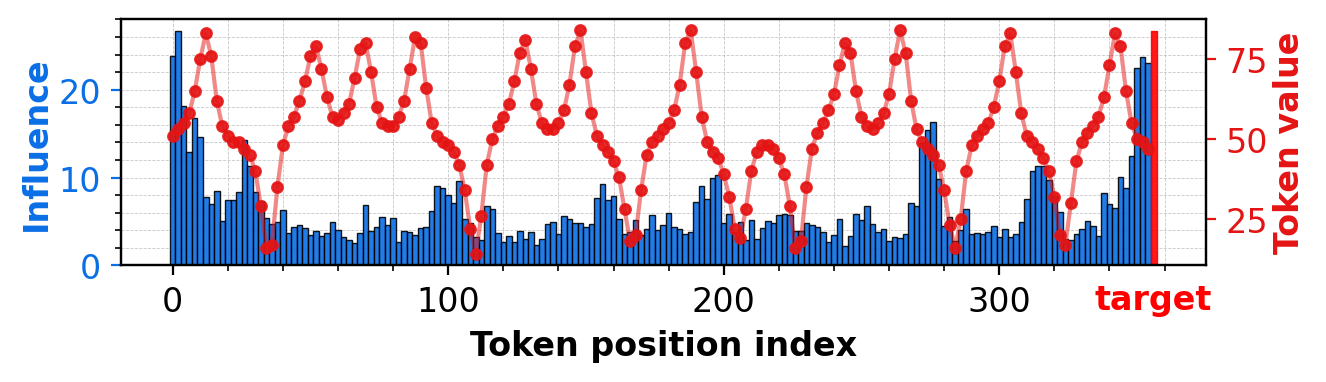

In [7]:
JacobianScopes.numerical_attribution_plotter(string, scores, grad_idx, front_pad, loss_position)